In [3]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
# from misc import  _clip_physical_params_intrinsic,compute_fft_with_windowing, calculate_detection_snr_0pa_vs_1pa, \
#     compute_fisher_parallelotope,covariance_from_fisher_parallelotope,inner_prod,load_startingpoint_param_array,\
#         calculate_time_max_0pa_vs_1pa,calculate_detection_overlap_0pa_vs_1pa,chi2_match,plot_time_series_from_fft,add_noise_func,check_noise_model_consistency

from misc import *
try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

# -----------------------------
# PARIS global context (picklable functions require module scope)
# -----------------------------..l
_PARIS_REF_CENTER = None          # type: Optional[np.ndarray]
_PARIS_SPREAD_SCALE = None        # type: Optional[float]
_PARIS_OBJECTIVE = None           # type: Optional[callable]
_PARIS_TARGET_KIND = None         # type: Optional[str]  # 'optimal_snr', 'optimal_snr_phase_max', 'phase_match', 'time_max'
# _PARIS_EARLY_STOP_HIT = False
_TARGET_SNR = None
# Fisher-parallelotope affine prior (primary for this script)
_PARIS_AFFINE_CENTER = None       # type: Optional[np.ndarray]
_PARIS_AFFINE_Q = None            # type: Optional[np.ndarray]
_PARIS_AFFINE_B = None            # type: Optional[np.ndarray]
_PARIS_DIM = None                 # type: Optional[int]
_PARIS_USE_ELLIPSE = True

cfg = Config()
# Target SNR for Fisher scaling
base_dir = cfg.basedir

def paris_prior_transform(u):
    """Prior transform using Fisher-parallelotope when configured.

    If affine parameters are set: theta = center + Q @ (b * t), with t = 2u-1.
    Otherwise falls back to multiplicative band around _PARIS_REF_CENTER.
    """
    u = np.asarray(u, dtype=float)
    if _PARIS_AFFINE_CENTER is not None and _PARIS_AFFINE_Q is not None and _PARIS_AFFINE_B is not None:
        center = _PARIS_AFFINE_CENTER
        Q = _PARIS_AFFINE_Q
        b = _PARIS_AFFINE_B
        dim = Q.shape[0]

        def map_one(u1):
            t = 2.0 * np.asarray(u1)[:dim] - 1.0
            return center + Q @ (b * t)

        if u.ndim == 1:
            theta = map_one(u)
            # if theta.shape[0] == 5:
            return _clip_physical_params_intrinsic(theta)
            # else:
            #     return check_and_clip_prior(theta, params_to_infer)
        else:
            out = np.zeros((u.shape[0], dim), dtype=float)
            for i in range(u.shape[0]):
                out[i] = map_one(u[i])
            return _clip_physical_params_intrinsic(out)
            # else:
            #     return check_and_clip_prior(out, params_to_infer)

    # Legacy multiplicative band (fallback)
    ref = _PARIS_REF_CENTER
    s = _PARIS_SPREAD_SCALE
    u = np.asarray(u)
    return ref * (1 - s + u * 2 * s)


def paris_inverse_prior_transform(params):
    """Inverse of paris_prior_transform.

    For affine Fisher mapping: t = diag(1/b) Q^T (theta - center), u = 0.5*(t+1).
    Falls back to multiplicative inverse if affine not configured.
    """
    theta = np.asarray(params, dtype=float)
    if _PARIS_AFFINE_CENTER is not None and _PARIS_AFFINE_Q is not None and _PARIS_AFFINE_B is not None:
        center = _PARIS_AFFINE_CENTER
        Q = _PARIS_AFFINE_Q
        b = _PARIS_AFFINE_B
        inv_b = 1.0 / b

        def inv_one(th):
            d = np.asarray(th) - center
            t = (Q.T @ d) * inv_b
            return 0.5 * (t + 1.0)

        if theta.ndim == 1:
            return inv_one(theta)
        out = np.zeros_like(theta, dtype=float)
        for i in range(theta.shape[0]):
            out[i] = inv_one(theta[i])
        return out

    ref = _PARIS_REF_CENTER
    s = _PARIS_SPREAD_SCALE
    return (theta / ref - (1 - s)) / (2 * s)


def paris_log_density(params):
    """Top-level log-density (score) wrapper without early-stop.

    - Receives physical parameters (after prior_transform) per parismc contract.
    - Returns a scalar/array of scores (larger is better).
    """
    params = np.asarray(params)

    def eval_one(x):
        try:
            val = float(_PARIS_OBJECTIVE(x))
        except Exception:
            return float('-inf')
        return val

    if params.ndim == 1:
        return eval_one(params)

    out = np.zeros(params.shape[0], dtype=float)
    for i in range(params.shape[0]):
        out[i] = eval_one(params[i])
    return out

def build_waveform_response(T: float, dt: float, use_gpu: bool = False) -> ResponseWrapper:
    """Create a LISA ResponseWrapper consistent with existing modules."""

    sum_kwargs = dict(pad_output=False, odd_len=True)
    
    waveform_model = GenerateEMRIWaveform(SuperKludgeWaveform, sum_kwargs=sum_kwargs, return_list=False,use_gpu=use_gpu)

    t0 = 10000.0
    tdi_gen = "2nd generation"
    order = 20
    index_lambda = 8  # phiS
    index_beta = 7    # qS

    response = ResponseWrapper(
        waveform_gen=waveform_model,
        Tobs=T,
        t0=t0,
        dt=dt,
        index_lambda=index_lambda,
        index_beta=index_beta,
        flip_hx=True,
        is_ecliptic_latitude=False,
        remove_garbage="zero",
        orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
        force_backend = "cuda12x" if use_gpu else "cpu",
        order=order,
        tdi=tdi_gen,
        tdi_chan="AET",
    )

    print("[INFO] Finished loading modules and building ResponseWrapper")
    return response

def prepare_true_waveform(signal_row: np.ndarray, emri_kwargs: dict, add_kwargs: dict,add_noise: bool=False, use_gpu: bool = False,seed: Optional[int] = 0) -> dict:
    """
    Build fiducial 1PA waveform, PSD, and FFT from a signal parameter row.
    signal_row columns:
      [m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    """
    (
        m1, m2, a, p0, e0, Y0,
        dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0
    ) = signal_row

    waveform_response = build_waveform_response(T=emri_kwargs['T'], dt=emri_kwargs['dt'], use_gpu=use_gpu)

    chi2 = add_kwargs.get('chi2')
    deviation_included = add_kwargs.get('deviation_included', True)
    add_kwargs['evolve_1PA'] = True
    evolve_1PA = add_kwargs['evolve_1PA']
    evolve_primary = add_kwargs.get('evolve_primary', False)
    evolve_2PA = add_kwargs.get('evolve_2PA',False)
    dev_1 = add_kwargs.get('dev_1')
    dev_2 = add_kwargs.get('dev_2')
    dt = emri_kwargs['dt']
    T=emri_kwargs['T']

    wave_params = [
        m1, m2, a, p0, e0, Y0,
        dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,chi2, evolve_1PA, evolve_primary, evolve_2PA, deviation_included, dev_1, dev_2
    ]
    # emri_kwargs = {"T": T, "dt": dt, 'chi2': chi2, 'evolve_1PA': evolve_1PA, 'evolve_primary': evolve_primary,
    #                 'evolve_2PA': evolve_2PA,'deviation_included': deviation_included,'dev_1': dev_1, 'dev_2': dev_2}

    waveform_true = xp.array(waveform_response(*wave_params, **emri_kwargs))
    print("[INFO] Finished generating true waveform")
    
    channels = [A1TDISens, E1TDISens, T1TDISens]
    noise_kwargs = [{"sens_fn": ch} for ch in channels]
    PSD_funcs = generate_PSD(
        waveform=waveform_true,
        dt=dt,
        noise_PSD=get_sensitivity,
        channels=channels,
        noise_kwargs=noise_kwargs,
        use_gpu=use_gpu,
    )

    # Verify SNR level (grid builder normalized dist to target PA2 SNR already)
    PSD_funcs_ = xp.array(PSD_funcs)

    # print("type check - waveform_true:", type(waveform_true), "PSD_funcs:", type(PSD_funcs_), "dt:", type(dt))
    print("shape check - waveform_true:", xp.shape(waveform_true), "PSD_funcs:", xp.shape(PSD_funcs_))
    snr_2 = inner_product(waveform_true, waveform_true, PSD_funcs_, dt, use_gpu=use_gpu)
    #if hasattribute get u
    snr = np.sqrt(snr_2.get()) if hasattr(snr_2, "get") else np.sqrt(snr_2)
    print(f"[TRUE] SNR: {snr:.6f}")     
    for i in range(PSD_funcs_.shape[0]):    
       #check snr of each channel
         snr_i_2 = inner_product(waveform_true[i:i+1,], waveform_true[i:i+1,], PSD_funcs_[i:i+1,:], dt, use_gpu=use_gpu)
         snr_i = np.sqrt(snr_i_2.get()) if hasattr(snr_i_2, "get") else np.sqrt(snr_i_2)
         print(f"[TRUE] SNR - Channel {i}: {snr_i:.6f}")
    
         
    N_fiducial = len(waveform_true[0])
    freq=np.fft.rfftfreq(N_fiducial, dt)
    delta_f = freq[1] - freq[0]
    print(f"[INFO] Frequency resolution delta_f: {delta_f:.6e} Hz, Number of frequency bins: {len(freq)}")
    print(f"freq_max: {freq[-1]:.6f} Hz and Freq_min: {freq[1]:.6f} Hz")

    if add_noise:
        waveform_true_fft_without_noise = compute_fft_with_windowing(waveform_true, dt, N_fiducial, use_gpu=use_gpu, n_channels=3)
        plot_time_series_from_fft(waveform_true_fft_without_noise, dt, title="True Waveform without Noise (Time Domain)")
        waveform_true_fft,_ = add_noise_func(waveform_true_fft_without_noise,PSD_funcs_,delta_f, dt,n_channels= 3,seed=cfg.seed)
        print("[INFO] Added noise to true waveform FFT\n")
        print("shape of waveform_true_fft after noise addition:", xp.shape(waveform_true_fft))
        plot_time_series_from_fft(waveform_true_fft, dt, title="True Waveform with Noise (Time Domain)")
        noise_dict = check_noise_model_consistency(PSD_funcs_,delta_f,dt,n_channels=3,temp_signal=waveform_true,seed=seed)
        print(f"Noise consistency check results: {noise_dict}")
        
    else:
        print("[INFO] No noise added to true waveform FFT\n")
        waveform_true_fft = compute_fft_with_windowing(waveform_true, dt, N_fiducial, use_gpu=use_gpu, n_channels=3)
        waveform_true_fft_without_noise = xp.copy(waveform_true_fft)  # Keep a copy of the clean FFT for later use
    
    print("[INFO] Finished preparing true waveform (GPU)")
    

    return {
        'm1': m1, 'm2': m2, 'a': a, 'p0': p0, 'e0': e0, 'Y0': Y0,
        'dist': dist, 'qS': qS, 'phiS': phiS, 'qK': qK, 'phiK': phiK,
        'Phi_phi0': Phi_phi0, 'Phi_theta0': Phi_theta0, 'Phi_r0': Phi_r0,
        'dt': dt, 'T': T, 'chi2': chi2,
        'dev_1': dev_1, 'dev_2': dev_2,
        'waveform_response': waveform_response,
        'PSD_funcs': PSD_funcs_,
        'waveform_true_fft': waveform_true_fft,
        'waveform_true_fft_without_noise': waveform_true_fft_without_noise,
        'N_fiducial': N_fiducial,
        'snr': snr,
        'delta_f': freq[1]-freq[0],
        'freq': freq,
        'noise_dict': noise_dict if add_noise else None,
    }

In [2]:
cd bias_inference_emri/src

/home/svu/e1583490/bias_inference_emri/src


In [4]:
def objective_factory(target_func: str,
                      ctx: dict,
                      phase_max: bool = False,
                      use_gpu_for_snr: bool = True,
                      infer_deviation_included: bool = False,
                      only_intrinsic_params: bool = False,
                      add_kwargs: dict = None,
                      analytic_model: str = None) -> callable:
    """
    Build a score(theta) where larger is better for all targets.
    - 'optimal_snr' and 'optimal_snr_phase_max': score = optimal SNR (maximize)
    - 'phase_match': score = -phase_diff_metric (maximize score => minimize phase diff)
    """
    # Only needed for SNR-based objective
    if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max','chi2_match'):
        fixed = {
            'waveform_response': ctx['waveform_response'],
            'PSD': ctx['PSD_funcs'],
            'dt': ctx['dt'],
            'T': ctx['T'],
            'N_fiducial': ctx['N_fiducial'],
            'waveform_true_fft': ctx['waveform_true_fft'],
            'xp': np,'delta_f': ctx['delta_f'],
            'use_gpu': bool(use_gpu_for_snr),
        }

    def score_optimal_snr(theta: np.ndarray) -> float:
        if only_intrinsic_params == True:
            if infer_deviation_included == False:
                m1, m2, a, p0, e0 = theta
                add_kwargs['evolve_1PA'] = False
                if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
                
                add_kwargs['deviation_included'] = False
                val = calculate_detection_snr_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],ctx['qS'],ctx['phiS'], ctx['qK'], ctx['phiK'], 
                    ctx['Phi_phi0'], ctx['Phi_theta0'], ctx['Phi_r0'],add_kwargs,
                    maximize_phase=bool(phase_max),
                    **fixed,)
                
            else:
                m1, m2, a, p0, e0, dev_1, dev_2 = theta
                add_kwargs['evolve_1PA'] = False
                if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
                add_kwargs['deviation_included'] = True
                add_kwargs['dev_1'] = dev_1
                add_kwargs['dev_2'] = dev_2
                val = calculate_detection_snr_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],ctx['qS'],ctx['phiS'], ctx['qK'], ctx['phiK'], 
                    ctx['Phi_phi0'], ctx['Phi_theta0'], ctx['Phi_r0'],add_kwargs,
                    maximize_phase=bool(phase_max),
                    **fixed,)

        else:
            if infer_deviation_included:
                m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = theta
                add_kwargs['dev_1'] = dev_1
                add_kwargs['dev_2'] = dev_2
                add_kwargs['evolve_1PA'] = False
                if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
                add_kwargs['deviation_included'] = True
                val = calculate_detection_snr_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs,
                    maximize_phase=bool(phase_max),
                    **fixed)
               # print(val, 'param', repr(theta))
                
            else:
                m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = theta
                add_kwargs['evolve_1PA'] = False
                if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
                add_kwargs['deviation_included'] = False
                val = calculate_detection_snr_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs,
                    maximize_phase=bool(phase_max),
                    **fixed)
                #print(val, 'param', repr(theta))
        # Score is the SNR itself (maximize)
        return float(val)
    
    def score_time_max(theta: np.ndarray) -> float:
        if only_intrinsic_params == True:
            if infer_deviation_included == False:
                m1, m2, a, p0, e0 = theta
                add_kwargs['evolve_1PA'] = False
                if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
                add_kwargs['deviation_included'] = False
                val = calculate_time_max_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],ctx['qS'],ctx['phiS'], ctx['qK'], ctx['phiK'], 
                    ctx['Phi_phi0'], ctx['Phi_theta0'], ctx['Phi_r0'],add_kwargs,
                    **fixed,)
                
            else:
                m1, m2, a, p0, e0, dev_1, dev_2 = theta
                add_kwargs['evolve_1PA'] = False
                if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
                add_kwargs['deviation_included'] = True
                add_kwargs['dev_1'] = dev_1
                add_kwargs['dev_2'] = dev_2
                val = calculate_time_max_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],ctx['qS'],ctx['phiS'], ctx['qK'], ctx['phiK'], 
                    ctx['Phi_phi0'], ctx['Phi_theta0'], ctx['Phi_r0'],add_kwargs,
                    **fixed,)

        else:
            if infer_deviation_included:
                m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = theta
                add_kwargs['dev_1'] = dev_1
                add_kwargs['dev_2'] = dev_2
                add_kwargs['evolve_1PA'] = False
                if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
                add_kwargs['deviation_included'] = True
                val = calculate_time_max_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs,
                    **fixed)
               # print(val, 'param', repr(theta))
                
            else:
                m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = theta
                add_kwargs['evolve_1PA'] = False
                if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
                add_kwargs['deviation_included'] = False
                val = calculate_time_max_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs,**fixed)
                #print(val, 'param', repr(theta))
        # Score is the SNR itself (maximize)
        return float(val)
    
    def score_chi2_match(theta: np.ndarray) -> float:
        if only_intrinsic_params == True:
            if infer_deviation_included == False:
                m1, m2, a, p0, e0 = theta
                add_kwargs['evolve_1PA'] = False
                if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
                add_kwargs['deviation_included'] = False
                val = chi2_match(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],ctx['qS'],ctx['phiS'], ctx['qK'], ctx['phiK'], 
                    ctx['Phi_phi0'], ctx['Phi_theta0'], ctx['Phi_r0'],add_kwargs,
                    **fixed,)
                
            else:
                m1, m2, a, p0, e0, dev_1, dev_2 = theta
                add_kwargs['evolve_1PA'] = False
                if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
                add_kwargs['deviation_included'] = True
                add_kwargs['dev_1'] = dev_1
                add_kwargs['dev_2'] = dev_2
                val = chi2_match(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],ctx['qS'],ctx['phiS'], ctx['qK'], ctx['phiK'], 
                    ctx['Phi_phi0'], ctx['Phi_theta0'], ctx['Phi_r0'],add_kwargs,
                    **fixed,)

        else:
            if infer_deviation_included:
                m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = theta
                add_kwargs['dev_1'] = dev_1
                add_kwargs['dev_2'] = dev_2
                add_kwargs['evolve_1PA'] = False
                if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
                add_kwargs['deviation_included'] = True
                val = chi2_match(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    ctx['Phi_phi0'], ctx['Phi_theta0'], ctx['Phi_r0'],add_kwargs,
                    **fixed)
               # print(val, 'param', repr(theta))
                
            else:
                m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = theta
                add_kwargs['evolve_1PA'] = False
                if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
                add_kwargs['deviation_included'] = False
                val = chi2_match(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs,**fixed)
                #print(val, 'param', repr(theta))
        # Score is the SNR itself (maximize)
        return float(val)

    # Phase-match uses trajectory frequency metric from phase-match.py logic
    # Here we re-implement a light-weight metric using FEW's fundamental frequencies.
  

    # Precompute 1PA Omega_phi(t) interpolation and frequency weights
    # Build 1PA trajectory from the signal row
    SK_traj_1PA = EMRIInspiral(func=KerrEccEqFlux)  # For 0PA vs 1PA metric we still compare to the same t-grid
    # Note: We only need 1PA ref already embedded in ctx? We rebuild Omega_phi_1PA curve here robustly
    # However ctx doesn’t include (t,p,e,x) of 1PA; reconstruct for phase metric
    from few.trajectory.inspiral import EMRIInspiral as EMRIInspiralFull
    from few.trajectory.ode.flux import SuperKludgeFlux

    SK_traj_true = EMRIInspiralFull(func=SuperKludgeFlux)

    # do we need to implement it inside the function
    add_kwargs["evolve_1PA"] = True
    traj_ref = SK_traj_true.get_inspiral(
        ctx['m1'], ctx['m2'], ctx['a'], ctx['p0'], ctx['e0'], ctx['Y0'],
        ctx['chi2'], add_kwargs["evolve_1PA"], add_kwargs['evolve_primary'], add_kwargs['evolve_2PA'],add_kwargs['deviation_included']
        ,add_kwargs['dev_1'],add_kwargs['dev_2'],Phi_phi0 = ctx['Phi_phi0'], Phi_theta0 = ctx['Phi_theta0'], Phi_r0 = ctx['Phi_r0'],
        T=ctx['T'], dt=ctx['dt'], err=1e-11, DENSE_STEPPING=False,
        buffer_length=1000, integrate_backwards=False,
        max_step_size=None,
    )
    t_ref, p_ref, e_ref, x_ref = traj_ref[0], traj_ref[1], traj_ref[2], traj_ref[3]
    Omega_phi_ref, _, _ = get_fundamental_frequencies(ctx['a'], p_ref, e_ref, x_ref)
    # Common time grid and 1PA omega interpolation
    t_common = np.linspace(t_ref.min(), t_ref.max(), 1000)
    Omega_phi_1PA_interp = CubicSpline(t_ref, Omega_phi_ref)(t_common)

    # Frequency weighting w(t) ~ sum 1/S_n(f_gw)
    m_mode = 2
    Msec = (ctx['m1'] + ctx['m2']) * MTSUN_SI
    Omega2_SI = Omega_phi_1PA_interp / Msec
    f_gw = m_mode * Omega2_SI / (2.0 * np.pi)
    w = np.zeros_like(f_gw)
    for ch in (A1TDISens, E1TDISens, T1TDISens):
        Sn = get_sensitivity(f_gw, sens_fn=ch)
        Sn = np.maximum(Sn, 1e-60)
        w += 1.0 / Sn
    add_kwargs["evolve_1PA"] = False
    if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
    def phase_metric_for_theta(theta: np.ndarray) -> float:
        # Supports both 0PA against 1PA reference
        if only_intrinsic_params == True:
            if infer_deviation_included == False:
                m1, m2, a, p0, e0 = theta
                add_kwargs['deviation_included'] = False
                add_kwargs['evolve_1PA'] = False
            else:
                m1, m2, a, p0, e0, dev_1, dev_2 = theta
                add_kwargs['dev_1'] = dev_1
                add_kwargs['dev_2'] = dev_2
                add_kwargs['deviation_included'] = True
                add_kwargs['evolve_1PA'] = False
        else:
            print("For entrinsic parameters, phase metric is not supported. Returning inf.")
            assert False, "For entrinsic parameters, phase metric is not supported. Returning inf."

        # Build trajectory for the chosen template order (0PA or 1PA) without 2PA
        SK_traj_tmpl = EMRIInspiral(func=KerrEccEqFlux)

        traj_0 = SK_traj_tmpl.get_inspiral(
            m1, m2, a, p0, e0, ctx['Y0'], add_kwargs['chi2'], add_kwargs['evolve_1PA'], add_kwargs['evolve_primary'], add_kwargs['evolve_2PA'],
            add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2'],
            Phi_phi0 = ctx['Phi_phi0'], Phi_theta0 = ctx['Phi_theta0'], Phi_r0 = ctx['Phi_r0'],
        T=ctx['T'], dt=ctx['dt'], err=1e-11, DENSE_STEPPING=False,
        buffer_length=1000, integrate_backwards=False,
        max_step_size=None,)

        t0, p0_arr, e0_arr, x0 = traj_0[0], traj_0[1], traj_0[2], traj_0[3]
        Omega_phi_0, _, _ = get_fundamental_frequencies(a, p0_arr, e0_arr, x0)
        # Interpolate to common grid
        Omega_phi_0_interp = CubicSpline(t0, Omega_phi_0)(t_common)
        # Weighted phase difference metric
        dOmega_geo = Omega_phi_0_interp - Omega_phi_1PA_interp
        dOmega_SI = dOmega_geo / Msec
        dphi = np.concatenate([[0.0], m_mode * cumulative_trapezoid(dOmega_SI, t_common)])
        num = np.trapezoid(w * dphi**2, t_common)
        den = np.trapezoid(w, t_common)
        res = np.sqrt(num / den)

        # theta_repr = "np.array(" + np.array2string(                   # Print theta as a copyable NumPy array with high precision
        #     theta,
        #     formatter={'float_kind': lambda x: f"{x:.12g}"},
        #     separator=', '
        # ) + ")"
        # print(f"{res:.6g}", 'param', theta_repr)
        return res

    def score_phase_match(theta: np.ndarray) -> float:
        # Lower phase difference should be better => use negative for a larger-is-better score
        return -float(phase_metric_for_theta(theta))

    if target_func in ('optimal_snr', 'optimal_snr_phase_max'):
        return score_optimal_snr
    elif target_func == 'phase_match':
        return score_phase_match
    elif target_func == 'time_max':
        return score_time_max
    elif target_func == 'chi2_match':
        return score_chi2_match
    else:
        raise ValueError(f"Unknown target_func: {target_func}")
        

In [5]:
def nelder_mead_optimize(theta0: np.ndarray, objective, maxiter: int = 3000, xatol: float = 1e-10, fatol: float = 1e-12):
    res = minimize(
        objective,
        theta0,
        method='Nelder-Mead',
        options={'maxiter': maxiter, 'maxfev': 15000, 'xatol': xatol, 'fatol': fatol,'adaptive': True},
    )
    return res


In [10]:
from scipy.optimize import differential_evolution
def differential_evolution_optimize(theta0: np.ndarray, objective, maxiter: int = 1000, tol: float = 1e-4, atol: float = 1e-5,x0: Optional[np.ndarray] = None,
                                    fisher_bounds: Optional[Tuple[np.ndarray, np.ndarray]] = None,init='sobol',seed: Optional[int] = 42):
    if fisher_bounds is not None:
        bounds = fisher_bounds
    else:
        bounds = [(x*(1-1e-3), x*(1+1e-3)) for x in theta0]  # Define bounds around initial guess
    res = differential_evolution(
        func=objective,
        bounds=bounds,
        maxiter=maxiter,
        tol=tol,
        atol=atol,
        x0=theta0,
        seed=seed,
        init=init

    )
    return res

In [11]:
def run_paris(ndim: int,
              prior_center: np.ndarray,
              score_func,
              spread_scale: float,
              savepath: str,
              seed_cloud: int = 10000,
              seed_jitter: float = 1e-10,
              paris_seed: int = 10,
              target_kind: str = None,
              lhs_save_dir: Optional[str] = None,
              affine_Q: Optional[np.ndarray] = None,
              affine_b: Optional[np.ndarray] = None,
              use_ellipse: bool = True):
    """Run PARIS sampler maximizing a score with a local prior around starting point.

    Notes on pickling:
    - parismc pickles the sampler, including log_density_func and prior_transform.
    - We therefore use top-level functions (paris_log_density/prior_transform) and
      set their behavior via module-level globals.
    """
    import parismc

    os.makedirs(savepath, exist_ok=True)

    # Configure global context for top-level callables
    global _PARIS_REF_CENTER, _PARIS_SPREAD_SCALE, _PARIS_OBJECTIVE, _PARIS_TARGET_KIND, _PARIS_EARLY_STOP_HIT
    global _PARIS_AFFINE_CENTER, _PARIS_AFFINE_Q, _PARIS_AFFINE_B, _PARIS_DIM
    global _PARIS_USE_ELLIPSE
    _PARIS_REF_CENTER = np.asarray(prior_center, dtype=float).copy()
    _PARIS_SPREAD_SCALE = float(spread_scale)
    _PARIS_OBJECTIVE = score_func
    _PARIS_TARGET_KIND = target_kind
    _PARIS_EARLY_STOP_HIT = False
    _PARIS_USE_ELLIPSE = bool(use_ellipse)

    # Configure Fisher-affine prior if provided
    if affine_Q is not None and affine_b is not None:
        _PARIS_AFFINE_CENTER = np.asarray(prior_center, dtype=float).copy()
        _PARIS_AFFINE_Q = np.asarray(affine_Q, dtype=float).copy()
        _PARIS_AFFINE_B = np.asarray(affine_b, dtype=float).copy()
        _PARIS_DIM = int(_PARIS_AFFINE_Q.shape[0])
    else:
        _PARIS_AFFINE_CENTER = None
        _PARIS_AFFINE_Q = None
        _PARIS_AFFINE_B = None
        _PARIS_DIM = None

    # Initialize sampler
    n_seed = paris_seed
    sigma = 1e-4
    init_cov_list = [sigma**2 * np.eye(ndim) for _ in range(n_seed)]
    config = parismc.SamplerConfig(
        merge_confidence=0.9,
        alpha=1000,
        #latest_prob_index=1000,
        trail_size=int(1e3),
        boundary_limiting=True,
        use_beta=True,
        integral_num=int(1e5),
        gamma=100,
        exclude_scale_z=np.inf,
        use_pool=False,
        cov_jitter=seed_jitter,  
      #  n_pool=36,
    )

    sampler = parismc.Sampler(
        ndim=ndim,
        n_seed=n_seed,
        log_density_func=paris_log_density,
        init_cov_list=init_cov_list,
        prior_transform=paris_prior_transform,
        config=config,
    )

    # Seed cloud in full unit cube; rely on Fisher-affine prior_transform for mapping
    unit_center = np.full(ndim, 0.5)
    center_val = float(paris_log_density(paris_prior_transform(unit_center.reshape(1, -1)))[0])

    point_blocks = [unit_center.reshape(1, -1)]
    log_blocks = [np.array([center_val])]

    n_samples = max(0, int(seed_cloud) - 1)
    if n_samples > 0:
        try:
            from smt.sampling_methods import LHS
        except ImportError as exc:
            raise RuntimeError(
                "smt.sampling_methods.LHS is required for PARIS seeding; install `smt` or ``pip install smt``"
            ) from exc

        xlimits = np.column_stack([
            np.zeros(ndim, dtype=float),
            np.ones(ndim, dtype=float),
        ])
        sampling = LHS(xlimits=xlimits)
        lhs_points = np.clip(sampling(n_samples), 0.0, 1.0)

        if lhs_points.ndim == 1:  # defensive: ensure (n, ndim)
            lhs_points = lhs_points.reshape(1, -1)

        # Require Fisher-affine mapping to be present
        if _PARIS_AFFINE_Q is None or _PARIS_AFFINE_B is None:
            raise RuntimeError("Fisher-affine prior is required for LHS seeding but is not set.")

        n_before = lhs_points.shape[0]
        if _PARIS_USE_ELLIPSE:
            # Fisher-ellipse truncation: keep points with ||t|| <= 1 where t = 2u-1
            t = 2.0 * lhs_points - 1.0
            keep_mask = np.sum(t * t, axis=1) <= 1.0
            lhs_points = lhs_points[keep_mask]
            n_after = lhs_points.shape[0]
            if n_after <= 0:
                raise RuntimeError("No LHS points remain after Fisher-ellipse truncation.")
            print(f"[LHS] before: {n_before}, after ellipse: {n_after}")
        else:
            print(f"[LHS] before: {n_before}, after ellipse: {n_before} (box)")

        print(f"[LHS] Sampled {lhs_points.shape[0]} points in unit cube; transforming to physical space with prior_transform")
        theta_points = paris_prior_transform(lhs_points)
        theta_min = np.min(theta_points, axis=0)
        theta_max = np.max(theta_points, axis=0)
        print(f"[LHS] theta_min: {repr(theta_min)}")
        print(f"[LHS] theta_max: {repr(theta_max)}")        


        lhs_vals = paris_log_density(paris_prior_transform(lhs_points))
        point_blocks.append(lhs_points)
        log_blocks.append(np.asarray(lhs_vals, dtype=float).reshape(-1))

    external_lhs_points = np.vstack(point_blocks)
    external_lhs_log_densities = np.concatenate(log_blocks)

    if lhs_save_dir:
        
        os.makedirs(lhs_save_dir, exist_ok=True)
        np.save(os.path.join(lhs_save_dir, 'lhs_points.npy'), np.asarray(external_lhs_points, dtype=float))
        np.save(os.path.join(lhs_save_dir, 'lhs_log_densities.npy'), np.asarray(external_lhs_log_densities, dtype=float))
        print(f"[INFO] Saved LHS points shape: {external_lhs_points.shape}, log-densities shape: {external_lhs_log_densities.shape}")

    max_idx = int(np.argmax(external_lhs_log_densities))
    max_point = external_lhs_points[max_idx]
    fallback_point = paris_prior_transform(max_point)
    fallback_score = float(external_lhs_log_densities[max_idx])
    sampler._fallback_best_point = np.asarray(fallback_point, dtype=float)
    sampler._fallback_best_score = fallback_score

    try:
        sampler.run_sampling(
            num_iterations=2000,
            savepath=savepath,
            print_iter=100,
            external_lhs_points=external_lhs_points,
            external_lhs_log_densities=external_lhs_log_densities,
        )
    except Exception as exc:
        print(f"[WARN] PARIS sampling failed: {exc}")
    return sampler, paris_prior_transform, external_lhs_points


Loaded starting point from /scratch/e1583490/emri_with_noise_0/nelder_mead_chi2_match_run_id_2/starting_point_3.npy: {'m1': np.float64(999990.1379724406), 'm2': np.float64(10.000077964766957), 'a': np.float64(0.899994608343531), 'p0': np.float64(7.500072066334388), 'e0': np.float64(0.499998393435243), 'xI0': 1.0, 'dist': 5.0, 'qS': np.float64(0.7852550443821964), 'phiS': np.float64(1.000168525927315), 'qK': 1.0, 'phiK': 1.0471975511965976, 'Phi_phi0': np.float64(0.9014342970017981), 'Phi_theta0': 0.5, 'Phi_r0': np.float64(0.404473998894285), 'dev_1': 0.0, 'dev_2': 0.0}
[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 3155814) PSD_funcs: (3, 1577907)
[TRUE] SNR: 56.117063
[TRUE] SNR - Channel 0: 29.274638
[TRUE] SNR - Channel 1: 24.652424
[TRUE] SNR - Channel 2: 41.041178
[INFO] Frequency resolution delta_f: 3.168755e-08 Hz, Number of frequency bins: 1577908
freq_max: 0.050000 Hz and Freq_min: 0.000000

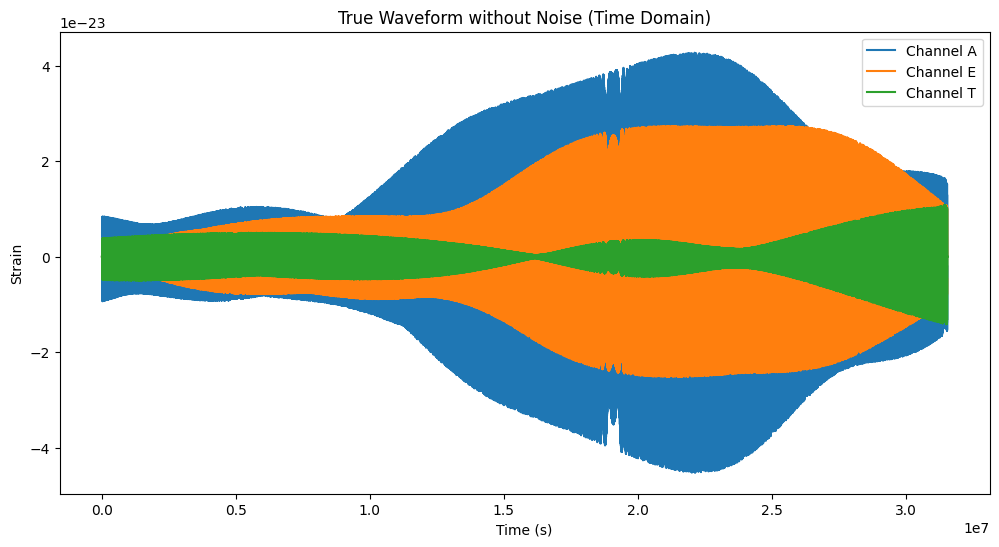

[INFO] Added noise to true waveform FFT

shape of waveform_true_fft after noise addition: (3, 1577907)


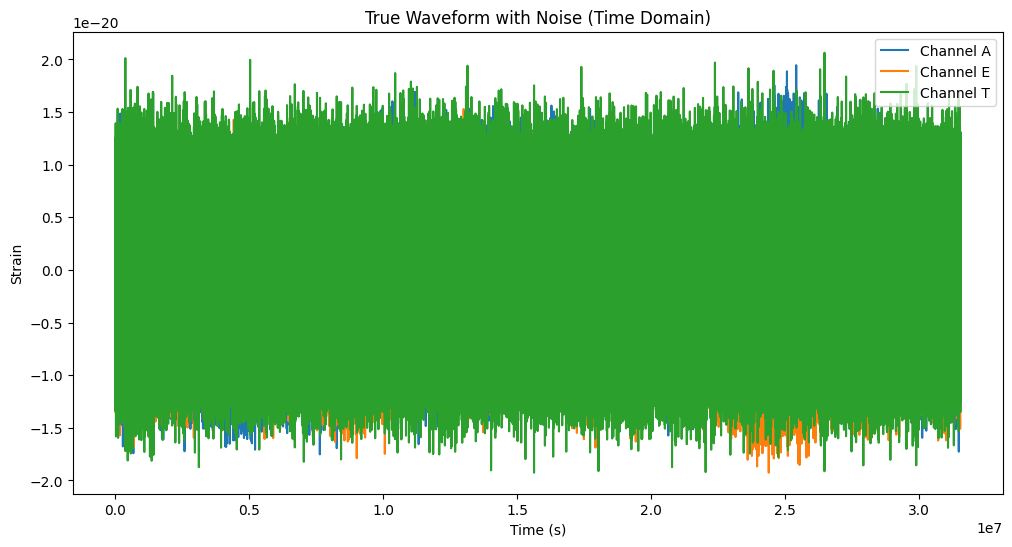

Length of PSD: 1577907


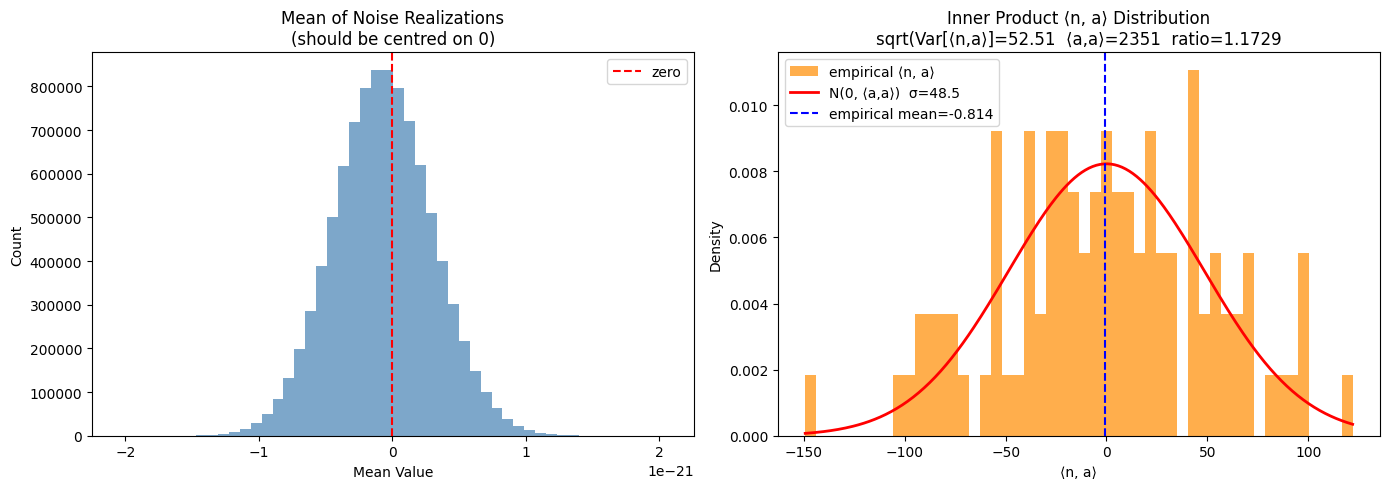

  Noise model consistency check
  Backend                : CuPy (GPU)
  Realizations           : 100
  N time samples         : 3155812  |  PSD bins passed: 1577906
  N (template samples)   : 3155814  →  aligned to 3155812
  Max |mean noise|       : 2.0551e-21  (expect ≈ 0)
  E[⟨n, a⟩]             : -8.1413e-01           (expect ≈ 0)
  Var[⟨n, a⟩]           : 2757.75
  ⟨a, a⟩                : 2351.33
  Ratio Var/⟨a,a⟩       : 1.172850          (expect ≈ 1.0)
Noise consistency check results: {'mean_noise': array([[-8.24851126e-22,  4.33131588e-22, -1.60594713e-22, ...,
        -2.14864290e-22,  6.75644221e-23,  9.17909493e-23],
       [-4.42571907e-22,  4.43612922e-24,  1.26346062e-22, ...,
        -2.83471365e-22, -1.41343948e-22,  3.19965441e-22],
       [-2.28135965e-22,  2.24084932e-22, -7.26844260e-23, ...,
        -8.38119872e-23, -6.52348843e-22,  4.92708503e-22]],
      shape=(3, 3155812)), 'inner_products': array([  56.50327042,  -54.86381078,   25.23093475,  -55.9357626 ,
    

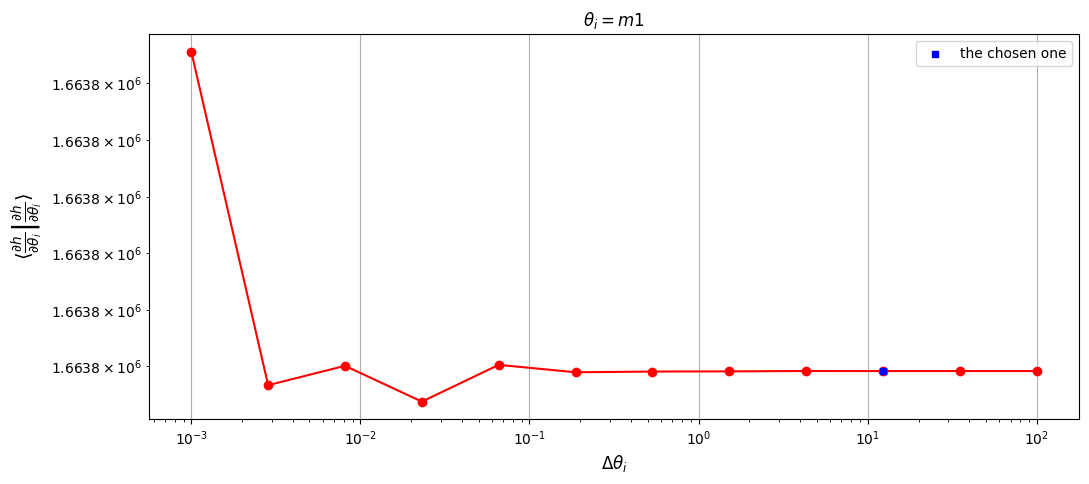

Gamma_ii for m2: 981816230099870.4
Gamma_ii for m2: 981816230094697.2
Gamma_ii for m2: 981816230183329.6
Gamma_ii for m2: 981816230105861.2
Gamma_ii for m2: 981816230735676.4
Gamma_ii for m2: 981816232382649.4
Gamma_ii for m2: 981816225110772.5
Gamma_ii for m2: 981816225253012.9
Gamma_ii for m2: 981816255261526.9
Gamma_ii for m2: 981816160868714.5
Gamma_ii for m2: 981816200309400.6
Gamma_ii for m2: 981816516699053.8
[np.float64(5.268934085048733e-12), np.float64(9.027389472208065e-11), np.float64(7.890313138503242e-11), np.float64(6.414796428126663e-10), np.float64(1.6774758306889704e-09), np.float64(7.406556022416066e-09), np.float64(1.4487474472459937e-10), np.float64(3.0564287196494436e-08), np.float64(9.61410253132123e-08), np.float64(4.017115027494049e-08), np.float64(3.222492672956119e-07)]
0


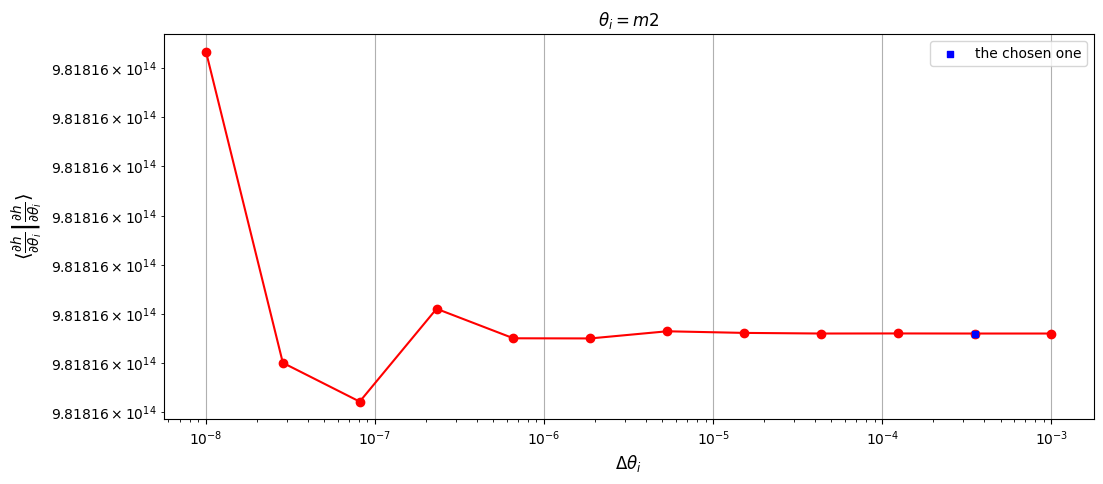

Gamma_ii for a: 5.983740977844403e+16
Gamma_ii for a: 5.983751254485579e+16
Gamma_ii for a: 5.983707587423744e+16
Gamma_ii for a: 5.983670175413377e+16
Gamma_ii for a: 5.983824395379984e+16
Gamma_ii for a: 5.984346094421074e+16
Gamma_ii for a: 5.9819180646383544e+16
Gamma_ii for a: 5.990179565249382e+16
Gamma_ii for a: 5.999860364186671e+16
Gamma_ii for a: 5.928084160678682e+16
Gamma_ii for a: 6.019938970091585e+16
Gamma_ii for a: 6.158491157996689e+16
[np.float64(1.717424528350231e-06), np.float64(7.297659719699077e-06), np.float64(6.25235169560719e-06), np.float64(2.5772809564109333e-05), np.float64(8.717728434455949e-05), np.float64(0.00040589485788384666), np.float64(0.0013791741167418674), np.float64(0.0016135040400396233), np.float64(0.012107824646634612), np.float64(0.01525842867664583), np.float64(0.0224977489372858)]
0


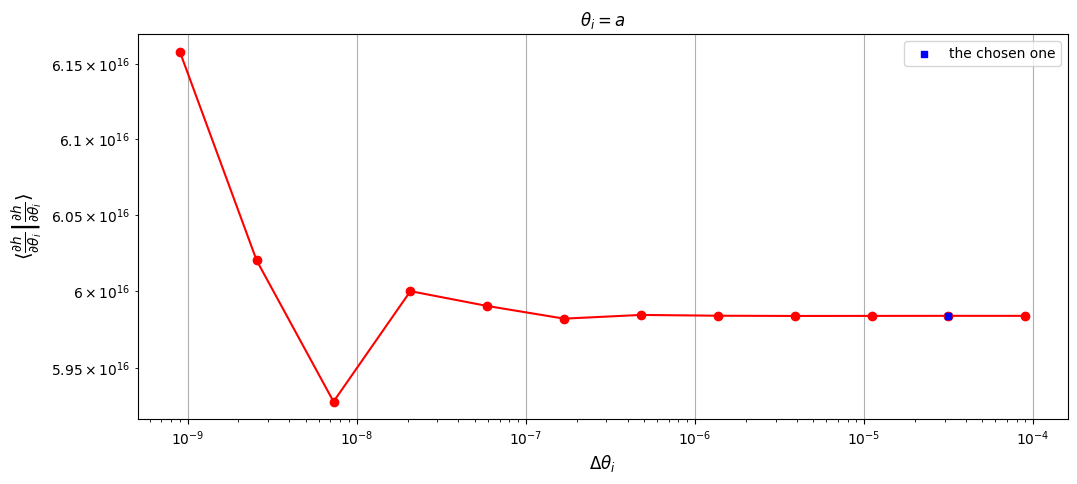

Gamma_ii for p0: 7.768840198810357e+16
Gamma_ii for p0: 7.768840163382365e+16
Gamma_ii for p0: 7.768845041161712e+16
Gamma_ii for p0: 7.768841875016386e+16
Gamma_ii for p0: 7.768855540527437e+16
Gamma_ii for p0: 7.768928206688134e+16
Gamma_ii for p0: 7.768456073923202e+16
Gamma_ii for p0: 7.769025254781051e+16
Gamma_ii for p0: 7.767420216285168e+16
Gamma_ii for p0: 7.767028381895003e+16
Gamma_ii for p0: 7.794516506531011e+16
Gamma_ii for p0: 7.691136215666386e+16
[np.float64(4.5602678462849864e-09), np.float64(6.278641575879087e-07), np.float64(4.075440557725758e-07), np.float64(1.7590121195987939e-06), np.float64(9.353434446085237e-06), np.float64(6.0775623938665714e-05), np.float64(7.32628404701512e-05), np.float64(0.00020663726838391947), np.float64(5.0448430326090824e-05), np.float64(0.0035265977835797447), np.float64(0.013441484842518602)]
0


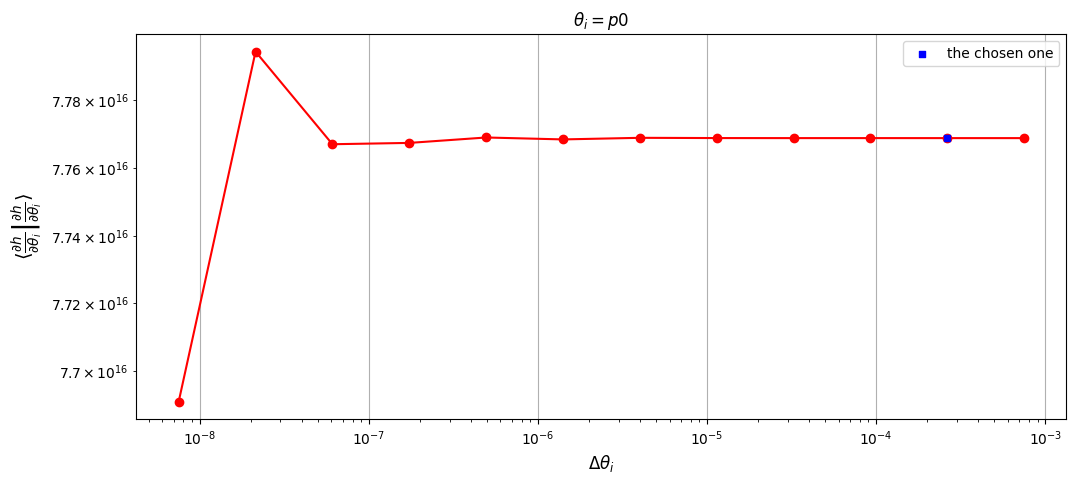

Gamma_ii for e0: 6.326005513540636e+17
Gamma_ii for e0: 6.326003408800694e+17
Gamma_ii for e0: 6.326001239308346e+17
Gamma_ii for e0: 6.325967587330803e+17
Gamma_ii for e0: 6.32584807583532e+17
Gamma_ii for e0: 6.325791746633409e+17
Gamma_ii for e0: 6.327748046512065e+17
Gamma_ii for e0: 6.330863909021603e+17
Gamma_ii for e0: 6.319154453612882e+17
Gamma_ii for e0: 6.319524938132749e+17
Gamma_ii for e0: 6.326564995545537e+17
Gamma_ii for e0: 6.2787744551368e+17
[np.float64(3.3271242621714365e-07), np.float64(3.4294845449590866e-07), np.float64(5.319656965962927e-06), np.float64(1.8892564925707398e-05), np.float64(8.904688008583027e-06), np.float64(0.0003091621006835658), np.float64(0.0004921701926173323), np.float64(0.00185300984406639), np.float64(5.8625375086556475e-05), np.float64(0.0011127772207738804), np.float64(0.007611444040586426)]
0


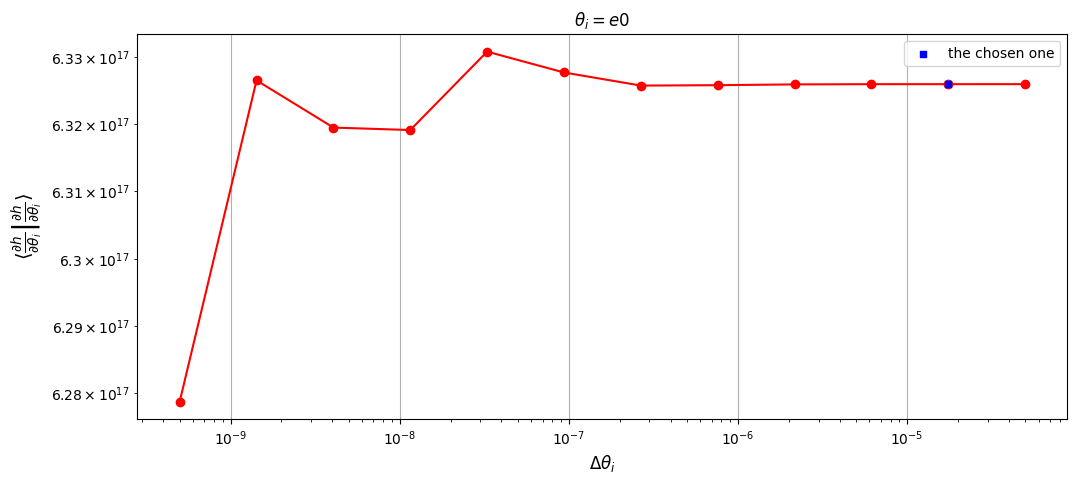

Gamma_ii for qS: 57490527.53067288
Gamma_ii for qS: 57840496.61110041
Gamma_ii for qS: 58741416.58360468
Gamma_ii for qS: 56607879.8314931
Gamma_ii for qS: 53913685.93153794
Gamma_ii for qS: 55340771.60263302
Gamma_ii for qS: 55379202.92864866
Gamma_ii for qS: 55350357.59724475
Gamma_ii for qS: 54992168.728589125
Gamma_ii for qS: 54775869.26845711
Gamma_ii for qS: 54623998.09470261
Gamma_ii for qS: 54692580.658959925
[np.float64(0.006050589136199962), np.float64(0.015337048796261434), np.float64(0.037689748467219744), np.float64(0.049972355875952744), np.float64(0.02578723840972218), np.float64(0.0006939667597807751), np.float64(0.0005211408318949504), np.float64(0.006513452313972991), np.float64(0.003948809266210488), np.float64(0.0027803013153888255), np.float64(0.0012539646773109593)]
6


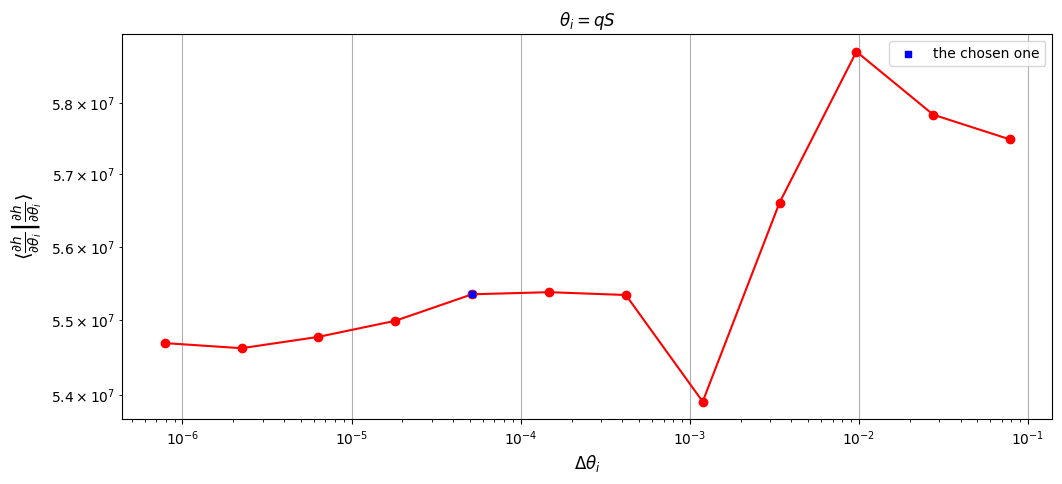

Gamma_ii for phiS: 52005967.1368313
Gamma_ii for phiS: 157250893.79336366
Gamma_ii for phiS: 157332181.96680105
Gamma_ii for phiS: 158529490.2685216
Gamma_ii for phiS: 158621521.463727
Gamma_ii for phiS: 158642725.62558857
Gamma_ii for phiS: 158645088.97491798
Gamma_ii for phiS: 158672268.2598958
Gamma_ii for phiS: 159130656.55960736
Gamma_ii for phiS: 157062278.86809334
Gamma_ii for phiS: 156885076.67376664
Gamma_ii for phiS: 156870168.05901796
[np.float64(0.6692803081604738), np.float64(0.0005166659002704197), np.float64(0.007552590370993598), np.float64(0.0005801936228838646), np.float64(0.00013365984338678386), np.float64(1.4897084710801433e-05), np.float64(0.00017129196724726612), np.float64(0.002880578196696195), np.float64(0.013169156250757794), np.float64(0.001129503188472033), np.float64(9.50379216976271e-05)]
5


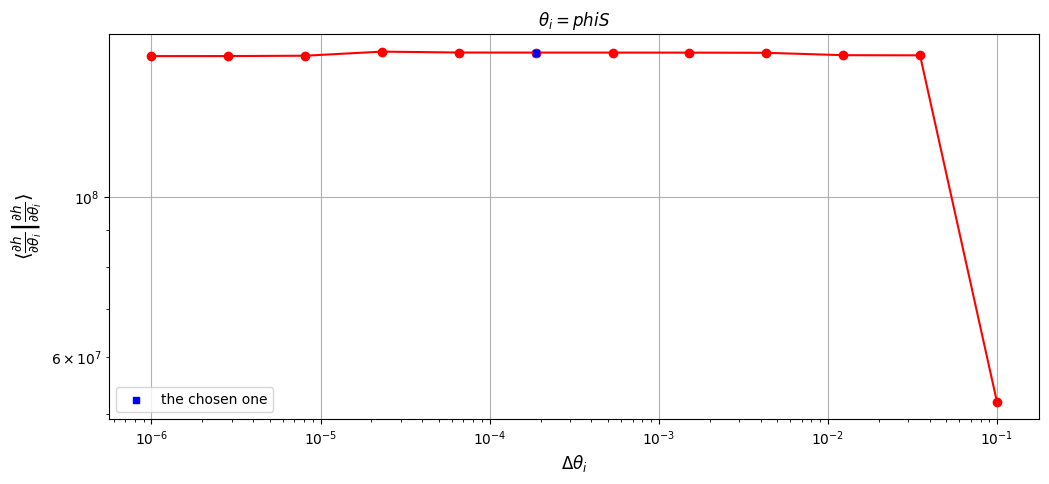

stable deltas: {'m1': 12.32846739442066, 'm2': 0.0003511191734215131, 'a': 3.160072560793623e-05, 'p0': 0.00026333938006613484, 'e0': 1.755595867107567e-05, 'qS': 5.1673954628421503e-05, 'phiS': 0.0001873817422860385, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 21.683218002319336 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 1.7980494499206543 seconds
[FISHER] array([[ 1.66380365e+06, -4.04156190e+10,  3.15502101e+11,
         3.59524588e+11,  1.02584993e+12, -9.57373667e+06,
         1.62428286e+07, -1.58960160e+06, -1.88956661e+06],
       [-4.04156190e+10,  9.81816230e+14, -7.66463735e+15,
        -8.73334719e+15, -2.49163606e+16,  2.32675325e+11,
        -3.94577989e+11,  3.86008024e+10,  4.58842420e+10],
       [ 3.15502101e+11, -7.66463735e+15,  5.98375125e+16,
         6.81769318e+16,  1.94503154e+17, -1.81652931e+12,
         3.08045959e+12, -3.01340563e+11, -3.5

/home/svu/e1583490/bias_inference_emri/.venv/lib/python3.12/site-packages/fastlisaresponse/response.py:670: SyntaxWarning: invalid escape sequence '\p'
  This class takes a waveform generator that produces :math:`h_+ \pm ih_x`.


KeyboardInterrupt: 

: 

In [ ]:
def main():

    cfg = Config()
    signal_param_array = cfg.params
    optimizer = cfg.optimizer
    target_func = cfg.target_func
    base_dir =cfg.basedir
    timestamp = time.strftime('%Y%m%d-%H%M%S')
    #add starting point#
    
    parameter_selected = cfg.parameter_selected
    run_type = cfg.run_type
    dt = cfg.dt
    T = cfg.T
    chi2= cfg.chi2
    dev_1 = cfg.dev_1
    dev_2 = cfg.dev_2
    analytic_model = cfg.analytic_model
    
    startingpoints = cfg.startingpoints
    # Example: extract a digit (or number) before a known pattern
    match = re.search(r'(\d+)(?=\D*$)', startingpoints)
    if match:
        id = int(match.group(1))
    else:
        raise ValueError("Could not extract id from startingpoints")
    starting_point = load_startingpoint_param_array(startingpoints)
    print(f"Loaded starting point from {startingpoints}: {starting_point}")
    
    emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
    add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

    # if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
    ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=cfg.include_noise, use_gpu=True,seed=cfg.seed)

    snr_2 = inner_prod(ctx['waveform_true_fft_without_noise'], ctx['waveform_true_fft_without_noise'], ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
    #if hasattribute get u
    snr = np.sqrt(snr_2.get()) if hasattr(snr_2, "get") else np.sqrt(snr_2)
    _TARGET_SNR = snr
        
    temp_dict = {'waveform_true_fft': ctx['waveform_true_fft'], 'waveform_true_fft_without_noise': ctx['waveform_true_fft_without_noise'],
                  'PSD': ctx['PSD_funcs'], 'dt': ctx['dt'], 'T': ctx['T'],
                     'N_fiducial': ctx['N_fiducial'], 'delta_f': ctx['delta_f'], 'use_gpu': cfg.use_gpu,'analytic_model': analytic_model,
                      'waveform_response': ctx['waveform_response'],'xp': cp if cfg.use_gpu else np}
    
    for k in ['m1', 'm2', 'a', 'p0', 'e0', 'Y0', 'dist', 'qS', 'phiS', 'qK', 'phiK', 'Phi_phi0', 'Phi_theta0', 'Phi_r0', 'chi2','dt', 'T','dev_1','dev_2']:
        assert k in ctx, f"Missing {k} in 1PA context"

    # Initial theta from startingpoint array if available, else from signal row
    #plot_time_series_from_fft(ctx['waveform_true_fft'], ctx['dt'], title="True waveform" if cfg.include_noise else "True waveform (no noise)")

    add_kwargs['evolve_1PA'] = False
    if analytic_model == '1PA':
        add_kwargs['evolve_1PA'] = True
    if cfg.run_type == '0pa_vs_1pa' and cfg.parameter_selected == "intrinsic":
        #theta_names = ['m1', 'm2', 'a', 'p0', 'e0']
        if starting_point is not None:
            theta0 = np.array([starting_point['m1'], starting_point['m2'], starting_point['a'], starting_point['p0'], starting_point['e0']], dtype=float)
        else:
            theta0 = np.array([ctx['m1'], ctx['m2'], ctx['a'], ctx['p0'], ctx['e0']], dtype=float)
         
        initial_overlap =calculate_detection_overlap_0pa_vs_1pa(
                    m1=starting_point['m1'], m2=starting_point['m2'], a=starting_point['a'], p0=starting_point['p0'], e0=starting_point['e0'], Y0=ctx['Y0'], dist=ctx['dist'], qS=ctx['qS'], phiS=ctx['phiS'], qK=ctx['qK'], phiK=ctx['phiK'],
                    Phi_phi0=ctx['Phi_phi0'], Phi_theta0=ctx['Phi_theta0'], Phi_r0=ctx['Phi_r0'], add_kwargs=add_kwargs,
                    maximize_phase=False,
                    **temp_dict)
        print("Current  Overlap:", initial_overlap )
        ndim = 5
    elif cfg.run_type == '0pa_vs_1pa_dev' and cfg.parameter_selected == "intrinsic":
        #assert "Not implemented yet: deviation_included=True with intrinsic-only inference"
        #theta_names = ['m1', 'm2', 'a', 'p0', 'e0','dev_1','dev_2']
        if starting_point is not None:
            theta0 = np.array([starting_point['m1'], starting_point['m2'], starting_point['a'], starting_point['p0'],
                                starting_point['e0'], starting_point['dev_1'], starting_point['dev_2']], dtype=float)
        else:
            theta0 = np.array([ctx['m1'], ctx['m2'], ctx['a'], ctx['p0'], ctx['e0'], ctx['dev_1'], ctx['dev_2']], dtype=float)
        temp_kwargs = add_kwargs.copy()
        temp_kwargs['dev_1'] = theta0[5]
        temp_kwargs['dev_2'] = theta0[6]
        temp_kwargs['deviation_included'] = True
        temp_kwargs['evolve_1PA'] = False
        if analytic_model == '1PA':
            temp_kwargs['evolve_1PA'] = True
        initial_overlap= calculate_detection_overlap_0pa_vs_1pa(
                    m1=starting_point['m1'], m2=starting_point['m2'], a=starting_point['a'], p0=starting_point['p0'], e0=starting_point['e0'], Y0=ctx['Y0'], dist=ctx['dist'], qS=ctx['qS'], phiS=ctx['phiS'], qK=ctx['qK'], phiK=ctx['phiK'],
                    Phi_phi0=ctx['Phi_phi0'], Phi_theta0=ctx['Phi_theta0'], Phi_r0=ctx['Phi_r0'], add_kwargs=temp_kwargs,
                    maximize_phase=False,
                    **temp_dict)
        print("Current  Overlap:",initial_overlap)
        
        ndim = 7
    elif cfg.run_type == '0pa_vs_1pa' and cfg.parameter_selected == "extrinsic":
        #theta_names = ['m1', 'm2', 'a', 'p0', 'e0','qS', 'phiS', 'Phi_phi0', 'Phi_r0']
        if starting_point is not None:
            theta0 = np.array([starting_point['m1'], starting_point['m2'], starting_point['a'], starting_point['p0'], 
                               starting_point['e0'], starting_point['qS'], starting_point['phiS'], starting_point['Phi_phi0'],
                                 starting_point['Phi_r0']], dtype=float)
        else:
            theta0 = np.array([ctx['m1'], ctx['m2'], ctx['a'], ctx['p0'], ctx['e0'], ctx['qS'],
                                ctx['phiS'], ctx['Phi_phi0'], ctx['Phi_r0']], dtype=float)
        ndim = 9
        add_kwargs['evolve_1PA'] = False
        if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
        initial_overlap=calculate_detection_overlap_0pa_vs_1pa(
                    m1=starting_point['m1'], m2=starting_point['m2'], a=starting_point['a'], p0=starting_point['p0'], e0=starting_point['e0'], Y0=ctx['Y0'], dist=ctx['dist'], qS=starting_point['qS'], phiS=starting_point['phiS'], qK=ctx['qK'], phiK=ctx['phiK'],
                    Phi_phi0=starting_point['Phi_phi0'], Phi_theta0=ctx['Phi_theta0'], Phi_r0=starting_point['Phi_r0'], add_kwargs=add_kwargs,
                    maximize_phase=False,
                    **temp_dict) 
        print("Current  Overlap:",initial_overlap)
    
    elif cfg.run_type == '0pa_vs_1pa_dev' and cfg.parameter_selected == "extrinsic":
        #theta_names = ['m1', 'm2', 'a', 'p0', 'e0','qS', 'phiS', 'Phi_phi0', 'Phi_r0','dev_1','dev_2']
        if starting_point is not None:
            theta0 = np.array([starting_point['m1'], starting_point['m2'], starting_point['a'],
                                starting_point['p0'], starting_point['e0'], starting_point['qS'],
                                starting_point['phiS'], starting_point['Phi_phi0'], starting_point['Phi_r0'],
                                  starting_point['dev_1'], starting_point['dev_2']], dtype=float)
        else:
            theta0 = np.array([ctx['m1'], ctx['m2'], ctx['a'], ctx['p0'], ctx['e0'],
                                ctx['qS'], ctx['phiS'], ctx['Phi_phi0'], ctx['Phi_r0'], ctx['dev_1'], ctx['dev_2']], dtype=float)
        ndim = 11
        temp_kwargs = add_kwargs.copy()
        temp_kwargs['dev_1'] = theta0[9]
        temp_kwargs['dev_2'] = theta0[10]
        temp_kwargs['deviation_included'] = True
        temp_kwargs['evolve_1PA'] = False
        if analytic_model == '1PA':
            temp_kwargs['evolve_1PA'] = True
        initial_overlap = calculate_detection_overlap_0pa_vs_1pa(
                    m1=starting_point['m1'], m2=starting_point['m2'], a=starting_point['a'], p0=starting_point['p0'], e0=starting_point['e0'], Y0=ctx['Y0'], dist=ctx['dist'], qS=starting_point['qS'], phiS=starting_point['phiS'], qK=ctx['qK'], phiK=ctx['phiK'],
                    Phi_phi0=starting_point['Phi_phi0'], Phi_theta0=ctx['Phi_theta0'], Phi_r0=starting_point['Phi_r0'], add_kwargs=temp_kwargs,
                    maximize_phase=False,
                    **temp_dict) 
        print("Current  Overlap:",initial_overlap)
    
    else:  raise ValueError(f"Unsupported run_type {cfg.run_type} with parameter_selected {cfg.parameter_selected}")
    
    # Objective setup with tracker for fallback support
    #no 1PA for analysis manifold
    #del temp_dict
    
    phase_max_flag = (target_func == 'optimal_snr_phase_max')
    raw_objective = objective_factory(
        target_func=target_func,
        ctx=ctx,
        phase_max=phase_max_flag,
        infer_deviation_included= run_type == '0pa_vs_1pa_dev',
        only_intrinsic_params = parameter_selected == "intrinsic",
        add_kwargs=add_kwargs,
        analytic_model=analytic_model,
    )
    tracker = ObjectiveTracker(theta0)
    def tracked_objective(theta: np.ndarray) -> float:
        val = float(raw_objective(np.asarray(theta, dtype=float)))
        tracker.update(theta, val)
        return val
    try:
        tracked_objective(theta0)
    except Exception as exc:
        print(f"[WARN] Initial objective evaluation failed at theta0: {exc}")
        tracker._best_score = float('-inf')
        
    objective = tracked_objective
    result = None
    if optimizer == 'nelder-mead':
            try:
                # Constrain search to remain within relative deviation of original (ctx-based) parameters
                tol = 1e-6 #1e-8 1pa emri #1e-6
                theta_ref = theta0.copy()
                def bounded_objective(theta: np.ndarray) -> float:
                    # denom = np.abs(theta_ref) #+ 1e-30
                    # rel = np.abs(np.asarray(theta) - theta_ref) / denom
                    # if np.any(rel > tol):
                    #     return 1e7
                    # # Nelder–Mead minimizes; convert larger-is-better score to loss
                    score_val = objective(theta)
                    return -float(score_val)

                result = nelder_mead_optimize(
                    theta0,
                    bounded_objective,
                    maxiter=cfg.nm_maxiter,
                    xatol=cfg.nm_xatol,
                    fatol=cfg.nm_fatol,
                )
                best_score = -float(result.fun)
                tracker.update(result.x, best_score)
    
                # Per-index output directory named with best score and optimized point
                
                _opt_vals = result.x
                
                # _vals_str = '_'.join(f"{v:.6e}" for v in _opt_vals)
                idx_dir = os.path.join(base_dir, f"nelder_mead_{target_func}_run_id_{id}")
               # idx_dir = os.path.join(nealder_mead_dir, f"{best_score:.12g}_{_vals_str}")
                os.makedirs(idx_dir, exist_ok=True)
                
                out_name = os.path.join(idx_dir, f"opt_nelder-mead_{cfg.target_func}_{timestamp}_id_{id}.json")
                out = {
                    'optimizer': 'nelder-mead',
                    'target_func': cfg.target_func,
                    'theta0': theta0.tolist(),
                    'x': result.x.tolist(),
                    'fun': float(result.fun),
                    'best_score': best_score,
                    'success': bool(result.success),
                    'snr_ref_1pa': float(ctx.get('snr', np.nan)),
                    # 'initial_overlap': float(initial_overlap),
                    # 'final_overlap': float(final_overlap),
                }
                with open(out_name, 'w') as f:
                    json.dump(out, f, indent=2)
                
                print(f"Saved result: {out_name}")
                print(f"[RESULT] Best loss (=-score): {out['fun']:.6e}")
                print(f"[RESULT] Best score: {out['best_score']:.6e}")
                print(f"[RESULT] Best point: {out['x']}")
                if not result.success:
                    print(f"[WARN] Nelder-Mead optimization did not converge: {result.message}")
    
                match ndim:
                    case 5:
                        print(f"Optimized (m1, m2, a, p0, e0): {result.x}")
                        result_array = starting_point.copy()
                        starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0']
                        for i, key in enumerate(starting_point_keys):
                            result_array[key] = result.x[i]
                        print(f"Optimized parameters as array: {result_array}")
                        np.save(os.path.join(idx_dir, f"results_nelder_mead_{id+1}_time_{timestamp}.npy"), result_array)
                        np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                    case 7:
                        print(f"Optimized (m1, m2, a, p0, e0, dev_1, dev_2): {result.x}")
                        result_array = starting_point.copy()
                        starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'dev_1', 'dev_2']
                        for i, key in enumerate(starting_point_keys):
                            result_array[key] = result.x[i]
                        print(f"Optimized parameters as array: {result_array}")
                        np.save(os.path.join(idx_dir, f"results_nelder_mead_{id+1}_time_{timestamp}.npy"), result_array)
                        np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                    case 9:
                        print(f"Optimized (m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0): {result.x}")
                        result_array = starting_point.copy()
                        starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']
                        for i, key in enumerate(starting_point_keys):
                            result_array[key] = result.x[i]
                        print(f"Optimized parameters as array: {result_array}")
                        np.save(os.path.join(idx_dir, f"results_nelder_mead_{id+1}_time_{timestamp}.npy"), result_array)
                        np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                    case 11:
                        print(f"Optimized (m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_1, dev_2): {result.x}")
                        result_array = starting_point.copy()
                        starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0', 'dev_1', 'dev_2']
                        for i, key in enumerate(starting_point_keys):
                            result_array[key] = result.x[i]
                        print(f"Optimized parameters as array: {result_array}")
                        np.save(os.path.join(idx_dir, f"results_nelder_mead_{id+1}_time_{timestamp}.npy"), result_array)
                        np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                    case _:
                        print(f"Optimized parameters: {result.x}")

                add_kwargs['evolve_1PA'] = False

                add_kwargs['dev_1'] = result_array['dev_1'] if 'dev_1' in result_array else add_kwargs.get('dev_1', 0.0)
                add_kwargs['dev_2'] = result_array['dev_2'] if 'dev_2' in result_array else add_kwargs.get('dev_2', 0.0)
                final_overlap = calculate_detection_overlap_0pa_vs_1pa(
                    result_array['m1'], result_array['m2'], result_array['a'], result_array['p0'], result_array['e0'], ctx['Y0'],ctx['dist'],result_array['qS'],result_array['phiS'], ctx['qK'], ctx['phiK'], 
                    result_array['Phi_phi0'], ctx['Phi_theta0'], result_array['Phi_r0'],add_kwargs,
                    maximize_phase=False,
                    **temp_dict)
                print("Overlap of the best point:", final_overlap)
                out = {
                    'optimizer': 'nelder-mead',
                    'target_func': cfg.target_func,
                    'theta0': theta0.tolist(),
                    'x': result.x.tolist(),
                    'fun': float(result.fun),
                    'best_score': best_score,
                    'success': bool(result.success),
                    'snr_ref_1pa': float(ctx.get('snr', np.nan)),
                    'initial_overlap': float(initial_overlap),
                    'final_overlap': float(final_overlap),
                }
                
                Config.save_results_with_config(
                                        cfg=cfg,
                                        results=out,
                                        save_dir=idx_dir,
                                        filename_prefix=f"opt_nelder_mead_{cfg.target_func}_id_{id}"
                                    )
    
            except Exception as exc:
                print(f"[ERROR] Nelder-Mead optimization failed: {exc}")

    
    elif optimizer == 'differential_evolution':
                # Constrain search to remain within relative deviation of original (ctx-based) parameters
            tol = 1e-8 #1e-8 1pa emri #1e-6
            theta_ref = theta0.copy()
            try:
                import cupy as cP
                USE_GPU = True
            except ImportError:
                USE_GPU = False

            try:
                add_kwargs['evolve_1PA'] = False
                if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
                add_kwargs['deviation_included'] = True
                Q, b, fisher_meta = compute_fisher_parallelotope(
                    ctx=ctx,
                    params_to_infer=cfg.param_names_to_infer,
                    fisher_params=signal_param_array,
                    use_gpu=USE_GPU,
                    prior_sigma_range=float(cfg.prior_sigma_range),
                    using_evec=cfg.using_evec,
                    additional_kwargs=add_kwargs,
                    _TARGET_SNR= _TARGET_SNR,
                    build_waveform_response= build_waveform_response

                )
                diag_sigma = fisher_meta['diag_sigma']
                bounds = []
                for i in range(len(diag_sigma)):
                    bounds.append((theta_ref[i] - diag_sigma[i], theta_ref[i] + diag_sigma[i]))

                   
                def bounded_objective(theta: np.ndarray) -> float:
                    # denom = np.abs(theta_ref) #+ 1e-30
                    # rel = np.abs(np.asarray(theta) - theta_ref) / denom
                    # if np.any(rel > tol):
                    #     return 1e7
                    score_val = objective(theta)
                    return -float(score_val)
                
                print(f"theta0, for debug, remove: {theta0}")

                result = differential_evolution_optimize(
                    theta0=theta0,
                    objective=bounded_objective,
                    fisher_bounds=bounds,
                    maxiter=cfg.de_maxiter,
                    tol=tol,
                    seed=cfg.seed,
                )
                best_score = -float(result.fun)
                tracker.update(result.x, best_score)
    
                # Per-index output directory named with best score and optimized point
                
                _opt_vals = result.x
                
                # _vals_str = '_'.join(f"{v:.6e}" for v in _opt_vals)
                idx_dir = os.path.join(base_dir, f"differential_evolution_{target_func}_run_id_{id}")
               # idx_dir = os.path.join(nealder_mead_dir, f"{best_score:.12g}_{_vals_str}")
                os.makedirs(idx_dir, exist_ok=True)
                
                out_name = os.path.join(idx_dir, f"opt_differential_evolution_{cfg.target_func}_{timestamp}_id_{id}.json")
                out = {
                    'optimizer': 'differential_evolution',
                    'target_func': cfg.target_func,
                    'theta0': theta0.tolist(),
                    'x': result.x.tolist(),
                    'fun': float(result.fun),
                    'best_score': best_score,
                    'success': bool(result.success),
                    'snr_ref_1pa': float(ctx.get('snr', np.nan)),
                    # 'initial_overlap': float(initial_overlap),
                    # 'final_overlap': float(final_overlap),
                }
                with open(out_name, 'w') as f:
                    json.dump(out, f, indent=2)
                
                print(f"Saved result: {out_name}")
                print(f"[RESULT] Best loss (=-score): {out['fun']:.6e}")
                print(f"[RESULT] Best score: {out['best_score']:.6e}")
                print(f"[RESULT] Best point: {out['x']}")
                if not result.success:
                    print(f"[WARN] Differential Evolution optimization did not converge: {result.message}")

                match ndim:
                    case 5:
                        print(f"Optimized (m1, m2, a, p0, e0): {result.x}")
                        result_array = starting_point.copy()
                        starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0']
                        for i, key in enumerate(starting_point_keys):
                            result_array[key] = result.x[i]
                        print(f"Optimized parameters as array: {result_array}")
                        np.save(os.path.join(idx_dir, f"results_differential_evolution_{id+1}_time_{timestamp}.npy"), result_array)
                        np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                    case 7:
                        print(f"Optimized (m1, m2, a, p0, e0, dev_1, dev_2): {result.x}")
                        result_array = starting_point.copy()
                        starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'dev_1', 'dev_2']
                        for i, key in enumerate(starting_point_keys):
                            result_array[key] = result.x[i]
                        print(f"Optimized parameters as array: {result_array}")
                        np.save(os.path.join(idx_dir, f"results_differential_evolution_{id+1}_time_{timestamp}.npy"), result_array)
                        np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                    case 9:
                        print(f"Optimized (m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0): {result.x}")
                        result_array = starting_point.copy()
                        starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']
                        for i, key in enumerate(starting_point_keys):
                            result_array[key] = result.x[i]
                        print(f"Optimized parameters as array: {result_array}")
                        np.save(os.path.join(idx_dir, f"results_differential_evolution_{id+1}_time_{timestamp}.npy"), result_array)
                        np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                    case 11:
                        print(f"Optimized (m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_1, dev_2): {result.x}")
                        result_array = starting_point.copy()
                        starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0', 'dev_1', 'dev_2']
                        for i, key in enumerate(starting_point_keys):
                            result_array[key] = result.x[i]
                        print(f"Optimized parameters as array: {result_array}")
                        np.save(os.path.join(idx_dir, f"results_differential_evolution_{id+1}_time_{timestamp}.npy"), result_array)
                        np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                    case _:
                        print(f"Optimized parameters: {result.x}")

                add_kwargs['evolve_1PA'] = False

                add_kwargs['dev_1'] = result_array['dev_1'] if 'dev_1' in result_array else add_kwargs.get('dev_1', 0.0)
                add_kwargs['dev_2'] = result_array['dev_2'] if 'dev_2' in result_array else add_kwargs.get('dev_2', 0.0)
                final_overlap = calculate_detection_overlap_0pa_vs_1pa(
                    result_array['m1'], result_array['m2'], result_array['a'], result_array['p0'], result_array['e0'], ctx['Y0'],ctx['dist'],result_array['qS'],result_array['phiS'], ctx['qK'], ctx['phiK'], 
                    result_array['Phi_phi0'], ctx['Phi_theta0'], result_array['Phi_r0'],add_kwargs,
                    maximize_phase=False,
                    **temp_dict)
                print("Overlap of the best point:", final_overlap)
                out = {
                    'optimizer': 'differential_evolution',
                    'target_func': cfg.target_func,
                    'theta0': theta0.tolist(),
                    'x': result.x.tolist(),
                    'fun': float(result.fun),
                    'best_score': best_score,
                    'success': bool(result.success),
                    'snr_ref_1pa': float(ctx.get('snr', np.nan)),
                    'initial_overlap': float(initial_overlap),
                    'final_overlap': float(final_overlap),
                }
                
                Config.save_results_with_config(
                                        cfg=cfg,
                                        results=out,
                                        save_dir=idx_dir,
                                        filename_prefix=f"opt_differential_evolution_{cfg.target_func}_id_{id}"
                                    )
    
            except Exception as exc:
                print(f"[ERROR] Differential Evolution optimization failed: {exc}")
                
                
    elif optimizer == 'paris':
        # --- PARIS Optimization Block ---

        try:
        # if True:
            # ---------------------------
            # Fisher prior computation
            # ---------------------------
            try:
                import cupy as cP
                USE_GPU = True
            except ImportError:
                USE_GPU = False

            try:
                add_kwargs['evolve_1PA'] = False
                if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True
                add_kwargs['deviation_included'] = True
                Q, b, fisher_meta = compute_fisher_parallelotope(
                    ctx=ctx,
                    params_to_infer=cfg.param_names_to_infer,
                    fisher_params=signal_param_array,
                    use_gpu=USE_GPU,
                    prior_sigma_range=float(cfg.prior_sigma_range),
                    using_evec=cfg.using_evec,
                    additional_kwargs=add_kwargs,
                    _TARGET_SNR= _TARGET_SNR,
                    build_waveform_response= build_waveform_response

                )
                print("Fisher parallelotope computed successfully.")
                fisher_ok = True

            except Exception as e:
                raise RuntimeError(f"[FATAL] Fisher prior failed: {e}") from e

            # ---------------------------
            # Directory setup
            # ---------------------------
            idx_dir = os.path.join(base_dir, f"paris_{cfg.target_func}_id_{id}")
            os.makedirs(idx_dir, exist_ok=True)

            savepath = os.path.join(idx_dir, f"paris_results_{cfg.target_func}_{timestamp}_id_{id}")
            lhs_seed_rel = "lhs_seed"
            lhs_seed_dir = os.path.join(idx_dir, lhs_seed_rel)

            # ---------------------------
            # Run PARIS optimizer
            # ---------------------------
            sampler, prior_transform, ext_points = run_paris(
                ndim=ndim,
                prior_center=theta0,
                score_func=objective,
                spread_scale=float(cfg.spread_scale),
                savepath=savepath,
                seed_cloud=int(cfg.seed_cloud),
                seed_jitter=1e-10,
                paris_seed = int(cfg.paris_seed_n),
                target_kind=cfg.target_func,
                lhs_save_dir=lhs_seed_dir,
                affine_Q=Q if fisher_ok else None,
                affine_b=b if fisher_ok else None,
                use_ellipse=bool(fisher_meta.get("using_evec", False)),
            )

            # ---------------------------
            # Extract best point
            # ---------------------------
            def extract_best_point():
                try:
                    pts = sampler.searched_points_list
                    logs = sampler.searched_log_densities_list

                    if not pts or not logs:
                        raise ValueError("Empty PARIS search results")

                    # best_unit = pts[0][int(np.argmax(logs[0]))]
                    best_unit = max((pts[i][np.argmax(logs[i])] for i in range(len(pts))),key=lambda u: paris_log_density(paris_prior_transform(u.reshape(1,-1)))[0])
                    return prior_transform(best_unit)

                except Exception as e:
                    print(f"[WARN] Best extraction failed: {e}, using fallback")

                    fallback = getattr(sampler, "_fallback_best_point", None)
                    if fallback is None:
                        raise RuntimeError("No fallback best point available") from e

                    return np.asarray(fallback, dtype=float)

            best_theta = extract_best_point()

            if best_theta is None:
                print("[WARN] Using starting point as fallback")
                best_theta = theta0

            best_theta = np.asarray(best_theta, dtype=float)

            # Transform if still in unit cube
            if np.all((best_theta >= 0.0) & (best_theta <= 1.0)):
                best_theta = prior_transform(best_theta)

            best_val = float(objective(best_theta))

            # ---------------------------
            # Local polishing (Gaussian steps)
            # ---------------------------
            best_fit_points = signal_param_array
            if cfg.parameter_selected == "intrinsic":
                if cfg.run_type == '0pa_vs_1pa':
                    best_fit_points[0:5] = best_theta

                elif cfg.run_type == '0pa_vs_1pa_dev':
                    best_fit_points[0:5] = best_theta
                    add_kwargs['dev_1'] = best_theta[5]
                    add_kwargs['dev_2'] = best_theta[6]
                else:
                    print(f"[WARN] Unsupported run_type {cfg.run_type} for best_fit_points assignment with parameter_selected=intrinsic")
            else:
                if cfg.run_type == '0pa_vs_1pa':
                    best_fit_points[0:5] = best_theta[0:5]
                    best_fit_points[7:9] = best_theta[5:7]
                    best_fit_points[11] = best_theta[7]
                    best_fit_points[13] = best_theta[8]

                elif cfg.run_type == '0pa_vs_1pa_dev':
                    best_fit_points[0:5] = best_theta[0:5]
                    best_fit_points[7:9] = best_theta[5:7]
                    best_fit_points[11] = best_theta[7]
                    best_fit_points[13] = best_theta[8]
                    add_kwargs['dev_1'] = best_theta[9]
                    add_kwargs['dev_2'] = best_theta[10]
                else:
                    print(f"[WARN] Unsupported run_type {cfg.run_type} for best_fit_points assignment with parameter_selected=extrinsic")


            Qp, bp, _ = compute_fisher_parallelotope(
                       ctx=ctx,
                    params_to_infer=cfg.param_names_to_infer,
                    fisher_params=best_fit_points,
                    use_gpu=USE_GPU,
                    prior_sigma_range=float(cfg.prior_sigma_range),
                    using_evec=cfg.using_evec,
                    additional_kwargs=add_kwargs,
                        _TARGET_SNR= _TARGET_SNR,
                    build_waveform_response= build_waveform_response
                )

            cov = covariance_from_fisher_parallelotope(
                Qp, bp, prior_sigma_range=float(cfg.prior_sigma_range)
            )

            rng = np.random.default_rng()
            ndim_local = len(best_theta)

            for _ in range(500):
                step = rng.multivariate_normal(
                    mean=np.zeros(ndim_local),
                    cov=1e-5 * cov,
                )

                cand = _clip_physical_params_intrinsic(best_theta + step)
                val = float(objective(cand))

                if val > best_val:
                    best_theta, best_val = cand, val

            tracker.update(best_theta, best_val)

            print(f"[POLISH] Final best score: {best_val:.6e}")
            print(f"[POLISH] Final best point: {best_theta.tolist()}")

            # ---------------------------
            # Rename directory based on result
            # ---------------------------
            # vals_str = ",".join(f"{float(v):.12g}" for v in best_theta)
            # new_idx_dir = os.path.join(base_dir, f"{best_val:.12g}_{vals_str}")

            # if os.path.abspath(new_idx_dir) != os.path.abspath(idx_dir):
            #     os.rename(idx_dir, new_idx_dir)
            #     idx_dir = new_idx_dir
            #     savepath = os.path.join(idx_dir, os.path.basename(savepath))

            lhs_seed_dir = os.path.join(idx_dir, lhs_seed_rel)

            # ---------------------------
            # Save outputs
            # ---------------------------
            out = {
                "optimizer": "PARIS",
                "target_func": cfg.target_func,
                "theta0": theta0.tolist(),
                "snr_ref_2pa": float(ctx.get("snr", np.nan)),
                "savepath": savepath,
                "fisher_prior": True,
                "fisher_meta": fisher_meta,
                "best_point": best_theta.tolist(),
                "best_score": best_val,
                "lhs_seed_dir": lhs_seed_dir,}

            json_path = os.path.join(idx_dir, f"opt_PARIS_{cfg.target_func}_{timestamp}.json")
            with open(json_path, "w") as f:
                json.dump(out, f, indent=2)

            np.save(
                os.path.join(idx_dir, f"score_PARIS_{cfg.target_func}_{timestamp}.npy"),
                np.array([best_val], dtype=float),
            )

            match ndim:
                        case 5:
                            print(f"Optimized (m1, m2, a, p0, e0): {best_theta}")
                            result_array = starting_point.copy()
                            starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0']
                            for i, key in enumerate(starting_point_keys):
                                result_array[key] = best_theta[i]
                            print(f"Optimized parameters as array: {result_array}")
                            np.save(os.path.join(idx_dir, f"results_paris_{id+1}_time_{timestamp}.npy"), result_array)
                            np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                        case 7:
                            print(f"Optimized (m1, m2, a, p0, e0, dev_1, dev_2): {best_theta}")
                            result_array = starting_point.copy()
                            starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'dev_1', 'dev_2']
                            for i, key in enumerate(starting_point_keys):
                                result_array[key] = best_theta[i]
                            print(f"Optimized parameters as array: {result_array}")
                            np.save(os.path.join(idx_dir, f"results_paris_{id+1}_time_{timestamp}.npy"), result_array)
                            np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                        case 9:
                            print(f"Optimized (m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0): {best_theta}")
                            result_array = starting_point.copy()
                            starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']
                            for i, key in enumerate(starting_point_keys):
                                result_array[key] = best_theta[i]
                            print(f"Optimized parameters as array: {result_array}")
                            np.save(os.path.join(idx_dir, f"results_paris_{id+1}_time_{timestamp}.npy"), result_array)
                            np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                        case 11:
                            print(f"Optimized (m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_1, dev_2): {best_theta}")
                            result_array = starting_point.copy()
                            starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0', 'dev_1', 'dev_2']
                            for i, key in enumerate(starting_point_keys):
                                result_array[key] = best_theta[i]
                            print(f"Optimized parameters as array: {result_array}")
                            np.save(os.path.join(idx_dir, f"results_paris_{id+1}_time_{timestamp}.npy"), result_array)
                            np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                        case _:
                            print(f"Optimized parameters: {best_theta}")

            add_kwargs['evolve_1PA'] = False
            if analytic_model == '1PA':
                    add_kwargs['evolve_1PA'] = True

            add_kwargs['dev_1'] = result_array['dev_1'] if 'dev_1' in result_array else add_kwargs.get('dev_1', 0.0)
            add_kwargs['dev_2'] = result_array['dev_2'] if 'dev_2' in result_array else add_kwargs.get('dev_2', 0.0)
            final_overlap = calculate_detection_overlap_0pa_vs_1pa(
                    result_array['m1'], result_array['m2'], result_array['a'], result_array['p0'], result_array['e0'], ctx['Y0'],ctx['dist'],result_array['qS'],result_array['phiS'], ctx['qK'], ctx['phiK'], 
                    result_array['Phi_phi0'], ctx['Phi_theta0'], result_array['Phi_r0'],add_kwargs,
                    maximize_phase=False,
                    **temp_dict)
            print("Overlap of the best point:", final_overlap)
            out = {
                "optimizer": "PARIS",
                "target_func": cfg.target_func,
                "theta0": theta0.tolist(),
                "snr_ref_2pa": float(ctx.get("snr", np.nan)),
                "savepath": savepath,
                "fisher_prior": True,
                "fisher_meta": fisher_meta,
                "best_point": best_theta.tolist(),
                "best_score": best_val,
                "lhs_seed_dir": lhs_seed_dir,
                "initial_overlap": float(initial_overlap),
                 "final_overlap": float(final_overlap),
            }
            Config.save_results_with_config(
            cfg=cfg,
            results=out,
            save_dir=idx_dir,
            filename_prefix=f"opt_PARIS_{cfg.target_func}_id_{id}")

        # ---------------------------
        # Global failure handler
        # ---------------------------
        except Exception as exc:
            print(f"[WARN] PARIS optimization failed: {exc}")
            

if __name__ == "__main__":
    main()

In [9]:
import numpy as np
# data = {
#     "m1": 1e6,
#     "m2": 1.00000000e+04,
#     "a": 0.9,
#     "p0": 2.85813146e+01,
#     "e0": 0.5,
#     "xI0": 1.0,
#     "dist": 3.31765439e+01,
#     "qS": 1.04719755e+00,
#     "phiS": 7.85398163e-01,
#     "qK": 6.28318531e-01,
#     "phiK": 5.23598776e-01,
#     "Phi_phi0": 1.00000000e-01,
#     "Phi_theta0": 0.2,
#     "Phi_r0": 3.00000000e-01,
#     "dev_1": 0.0,
#     "dev_2": 0.0,
# }
data = {
    "m1": 1e6,
    "m2": 5.00000000e+03,
    "a": 0.70,
    "p0": 25.0,
    "e0": 0.25,
    "xI0": 1.0,
    "dist": 3,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.0000e-01,
    "dev_1": 0.0,
    "dev_2": 0.0,
}
# Save as .npy file
np.save("starting_point_0.npy", data)


In [1]:
cd bias_inference_emri/src

/home/svu/e1583490/bias_inference_emri/src
